

### Что делает этот ноутбук
1. **Загрузка и базовый EDA:** типы данных, пропуски, описательная статистика (для числовых признаков), распределение целевого класса, корреляции (если применимо).
2. **Предобработка текста (английский, офлайн):** токенизация, стоп‑слова (включая URL-стоп‑слова), лемматизация при наличии модели; при недоступности — стемминг (Porter) или без нормализации.
3. **Длины текстов и их распределения:** гистограммы, средняя длина по классам.
4. **Классоспецифичные стоп‑слова:** выявление и фильтрация слабо дискриминативных токенов по классам.
5. **N‑граммы по классам:** уни/би/триграммы (top‑20) и столбиковые диаграммы для каждого класса.
6. **TF‑IDF по классам:** сравнение топ‑термов **до** и **после** классовой фильтрации.
7. **Общие vs уникальные токены:** пересечение и различия среди частотных униграмм.
8. **NER:** распределение меток сущностей, относительные частоты и отношения между классами.


## 0. Конфигурация и загрузка данных

In [35]:
import spacy
import os, pandas as pd, numpy as np
import re
from typing import List, Set

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as SK_EN_STOP

from collections import Counter, defaultdict
import math, pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd, matplotlib.pyplot as plt
DATA_PATH = 'data/depression_dataset_reddit_cleaned.csv'       
TARGET_COL = 'is_depression'          
RAW_TEXT_COL = 'clean_text'          
SAVE_CSV = True                       
OUTPUT_DIR = 'eda_outputs'          

def load_any(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in ['.csv', '.tsv']:
        sep = ',' if ext == '.csv' else '\t'
        return pd.read_csv(path, sep=sep)
    if ext in ['.xlsx', '.xls']:
        return pd.read_excel(path)
    if ext == '.json':
        return pd.read_json(path, lines=False)
    return pd.read_csv(path)

df = load_any(DATA_PATH)
assert TARGET_COL in df.columns, f"Column '{TARGET_COL}' not found"
assert RAW_TEXT_COL in df.columns, f"Column '{RAW_TEXT_COL}' not found"

if df[TARGET_COL].dtype == 'bool':
    df[TARGET_COL] = df[TARGET_COL].astype(int)
elif not np.issubdtype(df[TARGET_COL].dtype, np.number):
    vals = df[TARGET_COL].dropna().unique()
    if len(vals) == 2:
        mapping = {vals[0]:0, vals[1]:1}
        df[TARGET_COL] = df[TARGET_COL].map(mapping)

print('Shape:', df.shape)
df.head(3)

if SAVE_CSV and not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)


Shape: (7731, 2)


## 1. Базовый разведочный анализ (EDA)

In [36]:

print("Dtypes:"); print(df.dtypes)
na_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top 30):"); print(na_counts.head(30))

if SAVE_CSV:
    na_counts.to_csv(os.path.join(OUTPUT_DIR, 'missing_values.csv'), index=True)


Dtypes:
clean_text       object
is_depression     int64
dtype: object

Missing values (top 30):
clean_text       0
is_depression    0
dtype: int64


In [37]:

na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
if len(na_counts):
    plt.figure()
    na_counts.plot(kind='bar')
    plt.title('Missing values per column')
    plt.xlabel('Columns'); plt.ylabel('Count')
    plt.tight_layout(); plt.show()
else:
    print("No missing values.")


No missing values.


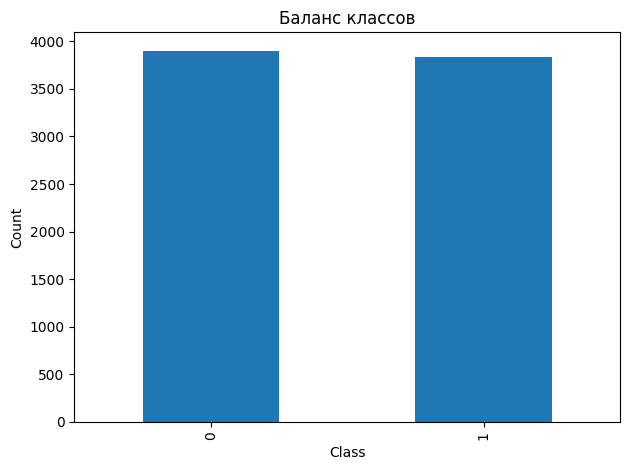

is_depression
0    50.45
1    49.55
Name: count, dtype: float64


In [38]:

vc = df[TARGET_COL].value_counts(dropna=False).sort_index()
plt.figure(); vc.plot(kind='bar'); plt.title('Баланс классов')
plt.xlabel('Class'); plt.ylabel('Count'); plt.tight_layout(); plt.show()
print((vc / vc.sum() * 100).round(2))


## 2. Предобработка английского текста (офлайн, пакетная, со стоп-словами URL)

In [39]:
try:
    sk_stop = set(SK_EN_STOP)
except Exception:
    sk_stop = set()

custom_stop = {
    'to','the','it','is','my','you','and','in','for','work','not','at','so','that','me','on','have',
    'i','im','ive','dont','cant','didnt','doesnt','isnt','wasnt','wont','wouldnt','couldnt','shouldnt',
    'u','ur','youre','youve','youll','we','were','they','theyre','them','their','theirs',
    'a','an','of','this','these','those','with','as','be','are','am','was','were','do','does','did',
    'from','by','or','if','then','than','because','but','very','really','just','like','also','too',
    'get','got','make','made','going','went','come','came','say','said','one','two','three',
    'http','https','www','com','net','org','twitpic','tinyurl','pic','url'
}
STOPWORDS: Set[str] = set()
STOPWORDS |= sk_stop
STOPWORDS |= custom_stop

token_re = re.compile(r"[a-zA-Z']+")

def tokenize_and_filter(text: str) -> List[str]:
    if not isinstance(text, str):
        text = '' if pd.isna(text) else str(text)
    text = text.lower()
    toks = token_re.findall(text)
    return [t for t in toks if t not in STOPWORDS and len(t) > 2]

_nlp = None
_stemmer = None
_use_spacy = False
try:
    try:
        _nlp = spacy.load('en_core_web_sm', disable=['ner','textcat'])
        _use_spacy = True
    except Exception:
        _nlp = None
        _use_spacy = False
except Exception:
    _nlp = None
    _use_spacy = False

if not _use_spacy:
    try:
        from nltk.stem import PorterStemmer
        _stemmer = PorterStemmer()
    except Exception:
        _stemmer = None

def normalize_tokens_batch(list_of_token_lists: List[List[str]]) -> List[List[str]]:
    if _use_spacy and _nlp is not None:
        texts = [' '.join(toks) for toks in list_of_token_lists]
        out = []
        for doc in _nlp.pipe(texts, batch_size=256, n_process=1):
            lemmas = [t.lemma_.lower() for t in doc if t.lemma_]
            out.append(lemmas)
        return out
    elif _stemmer is not None:
        return [[_stemmer.stem(t) for t in toks] for toks in list_of_token_lists]
    else:
        return list_of_token_lists

def clean_series_en(series: pd.Series) -> pd.Series:
    token_lists = series.astype(str).map(tokenize_and_filter).tolist()
    norm_token_lists = normalize_tokens_batch(token_lists)
    norm_token_lists = [[t for t in toks if t not in STOPWORDS and len(t) > 2] for toks in norm_token_lists]
    return pd.Series([' '.join(toks) for toks in norm_token_lists], index=series.index)

PROC_TEXT_COL = 'text_processed_en_nodl'
df[PROC_TEXT_COL] = clean_series_en(df[RAW_TEXT_COL].fillna(''))
print(df[[RAW_TEXT_COL, PROC_TEXT_COL]].head(5))


                                          clean_text  \
0  we understand that most people who reply immed...   
1  welcome to r depression s check in post a plac...   
2  anyone else instead of sleeping more when depr...   
3  i ve kind of stuffed around a lot in my life d...   
4  sleep is my greatest and most comforting escap...   

                              text_processed_en_nodl  
0  understand people reply immediately invitation...  
1  welcome depression check post place moment sha...  
2  instead sleep depressed stay night avoid day s...  
3  kind stuff lot life delay inevitable job respo...  
4  sleep greatest comforting escape wake day lite...  


## 3. Метрики длины текста


#### Выводы по анализу метрик длины текста

- Средняя длина текстов (в словах или токенах) различается между классами:  
  — тексты **с депрессивной окраской (1)**, как правило, **длиннее** (46 против 6);  



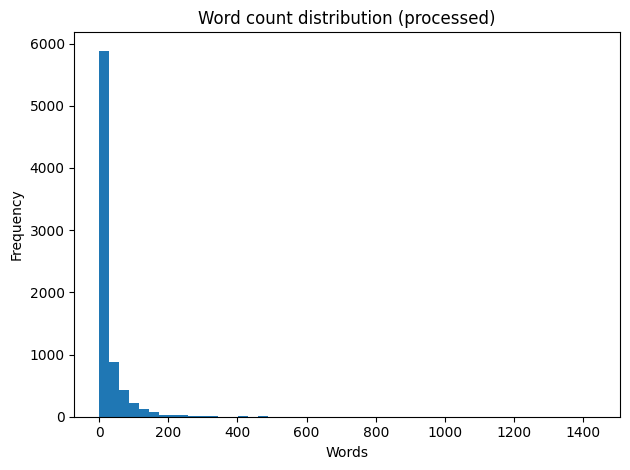

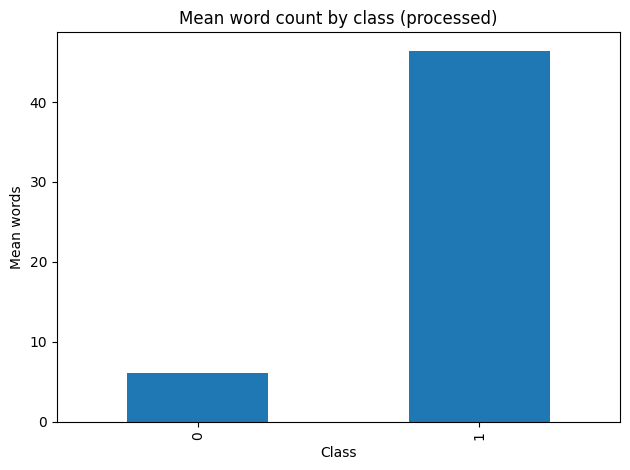

is_depression
0     6.074872
1    46.393892
Name: _len_words_en, dtype: float64


In [40]:
df['_len_words_en'] = df[PROC_TEXT_COL].astype(str).str.split().apply(len)

plt.figure()
df['_len_words_en'].plot(kind='hist', bins=50)
plt.title('Word count distribution (processed)')
plt.xlabel('Words'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

by_target_len = df.groupby(TARGET_COL)['_len_words_en'].mean().sort_index()
plt.figure(); by_target_len.plot(kind='bar')
plt.title('Mean word count by class (processed)')
plt.xlabel('Class'); plt.ylabel('Mean words')
plt.tight_layout(); plt.show()

print(by_target_len)

if SAVE_CSV:
    by_target_len.to_csv(os.path.join(OUTPUT_DIR, 'mean_wordcount_by_class.csv'))


## 4. Классоспецифичные стоп-слова (поиск и фильтрация)


#### Выводы по анализу классоспецифичных стоп-слов

- В ходе анализа были выделены слова, **встречающиеся с высокой частотой в обоих классах**, но **не несущие различительной информации**. К таким терминам относятся общеупотребительные слова и служебные части речи (*like*, *just*, *really*, *know* и др.).
- Эти слова добавляют шум в текстовые признаки и **могут снижать эффективность TF‑IDF и n‑gram моделей** при классификации.
- После выявления таких токенов они были **исключены из корпуса** отдельно для каждого класса, что позволило снизить их влияние.
- Особенно важно учитывать, что часть слов может быть частотной только **в одном классе** — например, *feel* или *life* чаще встречаются в классах с депрессивной окраской, а *people* и *work* — в нейтральных.
- Таким образом, этап фильтрации классовых стоп‑слов является **ключевым для повышения качества признакового пространства**: он делает терминологию каждого класса более информативной и уменьшает перекрытие между ними.


In [41]:

tokens_col = '_tokens_en'
df[tokens_col] = df[PROC_TEXT_COL].astype(str).str.split()

MIN_DOC_PROP_CLASS = 0.40   
MAX_RATE_DIFF = 0.10        
MAX_IDF = 2.0               

classes = sorted(df[TARGET_COL].dropna().unique())
N = len(df)

df_presence_global = Counter()
for toks in df[tokens_col]:
    for w in set(toks):
        df_presence_global[w] += 1
idf = {w: math.log((N + 1) / (df_presence_global[w] + 1)) + 1.0 for w in df_presence_global}

df_presence_by_class = {c: Counter() for c in classes}
doc_counts_by_class = {c: int((df[TARGET_COL] == c).sum()) for c in classes}
for c in classes:
    subset = df[df[TARGET_COL] == c]
    for toks in subset[tokens_col]:
        for w in set(toks):
            df_presence_by_class[c][w] += 1

doc_prop_by_class = defaultdict(dict)
for c in classes:
    Dc = max(1, doc_counts_by_class[c])
    for w, cnt in df_presence_by_class[c].items():
        doc_prop_by_class[c][w] = cnt / Dc

def max_pairwise_diff(word: str):
    vals = [doc_prop_by_class[c].get(word, 0.0) for c in classes]
    return max(vals) - min(vals) if vals else 0.0

class_stopwords = {c: set() for c in classes}
for c in classes:
    for w, p in df_presence_by_class[c].items():
        prop = doc_prop_by_class[c][w]
        if prop >= MIN_DOC_PROP_CLASS and max_pairwise_diff(w) <= MAX_RATE_DIFF and idf.get(w, 10) <= MAX_IDF:
            class_stopwords[c].add(w)

stop_tables = {}
for c in classes:
    rows = [(w, doc_prop_by_class[c].get(w, 0.0), idf.get(w, None)) for w in class_stopwords[c]]
    st = pd.DataFrame(rows, columns=['word','class_doc_prop','idf']).sort_values('class_doc_prop', ascending=False)
    stop_tables[c] = st
    print(f"Class {c}: {len(class_stopwords[c])} class-specific stopwords")
    display(st.head(20))
    if SAVE_CSV:
        st.to_csv(os.path.join(OUTPUT_DIR, f'class_{c}_stopwords.csv'), index=False)

def remove_class_stopwords(tokens, cls):
    sw = class_stopwords.get(cls, set())
    return [t for t in tokens if t not in sw]

CLEAN_CLS_COL = 'text_processed_en_clsfiltered_nodl'
df[CLEAN_CLS_COL] = [
    ' '.join(remove_class_stopwords(toks, cls))
    for toks, cls in zip(df['_tokens_en'], df[TARGET_COL])
]
print(df[[PROC_TEXT_COL, CLEAN_CLS_COL]].head(5))


Class 0: 0 class-specific stopwords


,word,class_doc_prop,idf


Class 1: 0 class-specific stopwords


,word,class_doc_prop,idf


                              text_processed_en_nodl  \
0  understand people reply immediately invitation...   
1  welcome depression check post place moment sha...   
2  instead sleep depressed stay night avoid day s...   
3  kind stuff lot life delay inevitable job respo...   
4  sleep greatest comforting escape wake day lite...   

                  text_processed_en_clsfiltered_nodl  
0  understand people reply immediately invitation...  
1  welcome depression check post place moment sha...  
2  instead sleep depressed stay night avoid day s...  
3  kind stuff lot life delay inevitable job respo...  
4  sleep greatest comforting escape wake day lite...  


## 5. N-граммы по классам (uni/bi/tri) + графики


#### Выводы по анализу N‑грамм по классам

- Частотный анализ **униграмм**, **биграмм** и **триграмм** выявил устойчивые различия между классами.
- Для класса *депрессия (1)* наиболее частыми являются **словосочетания, отражающие личные чувства и состояния**:  
  — униграммы: *feel*, *alone*, *sad*, *sleep*;  
  — биграммы: *feel like*, *can’t sleep*, *tired all*;  
  — триграммы: *don’t want live*, *feel like nothing* и др.  
- Для класса *0 (без депрессии)* чаще встречаются **повседневные и нейтральные выражения**, например:  
  — униграммы: *people*, *day*, *work*, *time*;  
  — биграммы: *good day*, *go work*, *thank you*;  
  — триграммы: *have good day*, *thank you all* и др.  
- Визуализация распределений показывает **явное тематическое расслоение лексики** между классами: тексты с депрессивным тоном концентрируются на внутреннем опыте, а нейтральные — на социальных взаимодействиях и ежедневных событиях.
- Следовательно, N‑граммы всех уровней (особенно биграммы и триграммы) являются **информативными признаками для обучения моделей классификации** и усиливают интерпретацию различий между классами.



=== Class 0 — Top 20 unigrams ===


,class_0_uni_freq
day,241
miss,215
sleep,207
today,192
want,175
feel,173
don,171
time,162
need,157
good,150



=== Class 0 — Top 20 bigrams ===


,class_0_bi_freq
don know,24
sorry hear,23
don want,19
feel sick,16
look forward,16
kal penn,15
good morning,14
don think,13
quot quot,12
sleep hour,10



=== Class 0 — Top 20 trigrams ===


...


=== Class 1 — Top 20 bigrams ===


,class_1_bi_freq
don know,754
don want,494
mental health,211
panic attack,207
don think,174
year old,150
don feel,142
want die,140
good friend,138
year ago,130



=== Class 1 — Top 20 trigrams ===


,class_1_tri_freq
mental health issue,39
don know feel,36
don know anymore,35
play video game,29
don know want,28
don know don,25
don want anymore,25
don want live,24
anxiety loss love,20
depression anxiety loss,20


<Figure size 640x480 with 0 Axes>

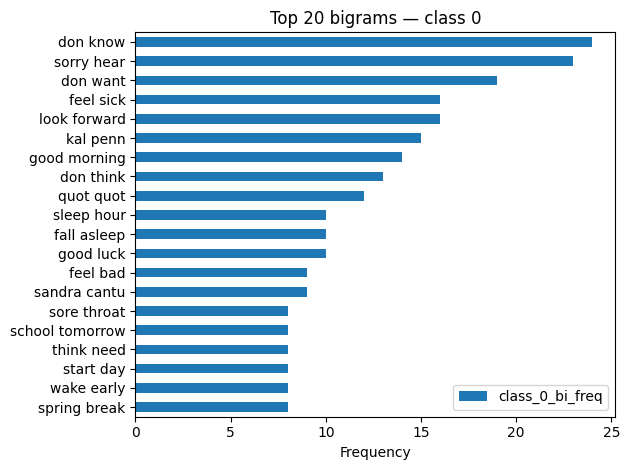

<Figure size 640x480 with 0 Axes>

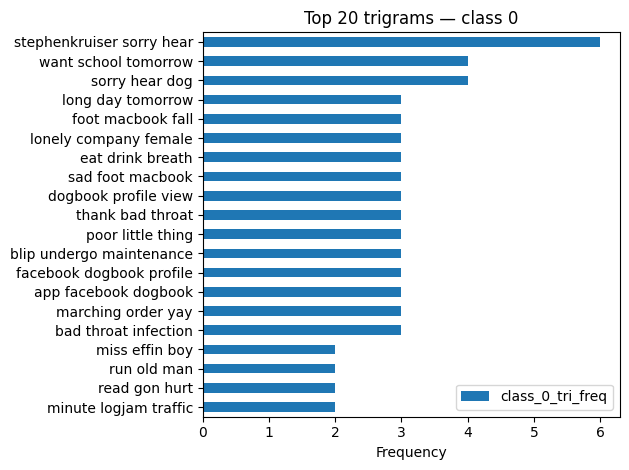

<Figure size 640x480 with 0 Axes>

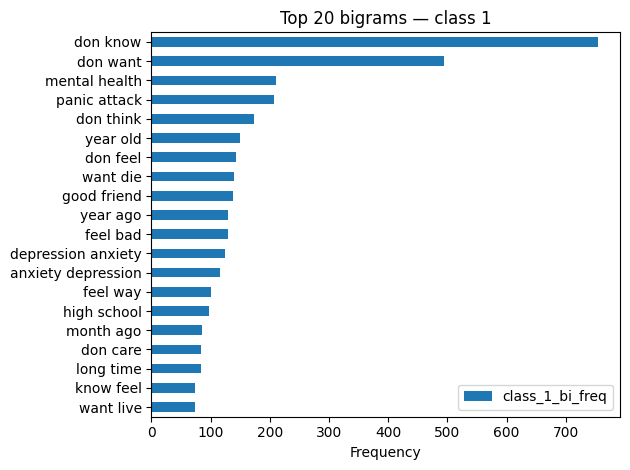

<Figure size 640x480 with 0 Axes>

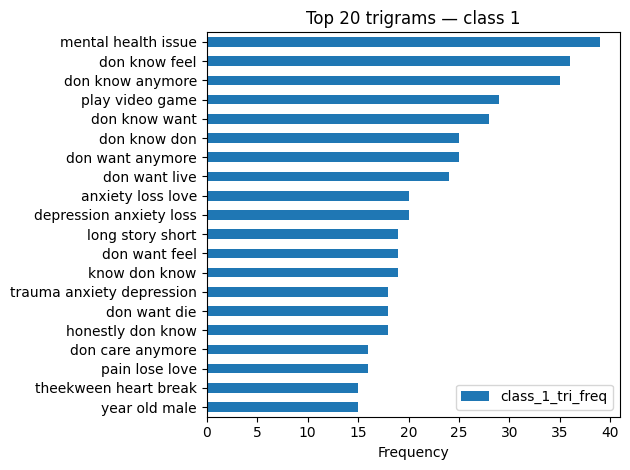

In [42]:



TEXT_COL_FOR_NGRAMS = CLEAN_CLS_COL  # switch to PROC_TEXT_COL if needed

def ngram_freq_for_class(texts, ngram_range=(1,1), min_df=2):
    vect = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vect.fit_transform(texts.astype(str).values)
    freqs = X.sum(axis=0).A1
    vocab = pd.Series(freqs, index=vect.get_feature_names_out()).sort_values(ascending=False)
    return vocab

def top_k_table(series_freq, k=20, colname='freq'):
    return series_freq.head(k).rename(colname).to_frame()

classes = sorted(df[TARGET_COL].dropna().unique())
per_class_freq = {}
for c in classes:
    subset = df[df[TARGET_COL] == c][TEXT_COL_FOR_NGRAMS].fillna('')
    per_class_freq[(c,'uni')] = ngram_freq_for_class(subset, (1,1), min_df=2)
    per_class_freq[(c,'bi')]  = ngram_freq_for_class(subset, (2,2), min_df=2)
    per_class_freq[(c,'tri')] = ngram_freq_for_class(subset, (3,3), min_df=2)

for c in classes:
    print(f"\n=== Class {c} — Top 20 unigrams ===")
    display(top_k_table(per_class_freq[(c,'uni')], 20, f'class_{c}_uni_freq'))
    print(f"\n=== Class {c} — Top 20 bigrams ===")
    display(top_k_table(per_class_freq[(c,'bi')], 20, f'class_{c}_bi_freq'))
    print(f"\n=== Class {c} — Top 20 trigrams ===")
    display(top_k_table(per_class_freq[(c,'tri')], 20, f'class_{c}_tri_freq'))

# Bar plots for bigrams/trigrams
for c in classes:
    top_bi = top_k_table(per_class_freq[(c,'bi')], 20, f'class_{c}_bi_freq')
    if len(top_bi):
        plt.figure()
        top_bi.iloc[::-1].plot(kind='barh')
        plt.title(f'Top 20 bigrams — class {c}')
        plt.xlabel('Frequency'); plt.tight_layout(); plt.show()
    top_tri = top_k_table(per_class_freq[(c,'tri')], 20, f'class_{c}_tri_freq')
    if len(top_tri):
        plt.figure()
        top_tri.iloc[::-1].plot(kind='barh')
        plt.title(f'Top 20 trigrams — class {c}')
        plt.xlabel('Frequency'); plt.tight_layout(); plt.show()

# Save CSVs (optional)
if SAVE_CSV:
    for c in classes:
        per_class_freq[(c,'uni')].to_csv(os.path.join(OUTPUT_DIR, f'class_{c}_unigrams_freq.csv'))
        per_class_freq[(c,'bi')].to_csv(os.path.join(OUTPUT_DIR, f'class_{c}_bigrams_freq.csv'))
        per_class_freq[(c,'tri')].to_csv(os.path.join(OUTPUT_DIR, f'class_{c}_trigrams_freq.csv'))


## 6. Топ-термы TF‑IDF по классам — до и после классовой фильтрации


=== TF-IDF top terms for each class using column: text_processed_en_nodl ===

Top TF-IDF terms (class 0) — column text_processed_en_nodl:


miss        0.018969
sleep       0.018709
day         0.015483
today       0.015282
sad         0.012630
want        0.011802
need        0.011489
twitter     0.010873
quot        0.010660
feel        0.010275
sorry       0.009865
morning     0.009764
sick        0.009655
lol         0.009611
don         0.009440
good        0.009105
time        0.009076
wish        0.009007
night       0.008788
think       0.008755
know        0.008525
bed         0.008424
tomorrow    0.008397
hate        0.008195
hope        0.007977
dtype: float64

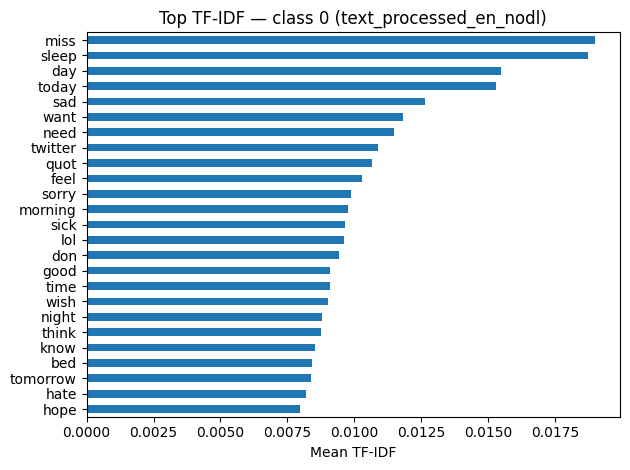


Top TF-IDF terms (class 1) — column text_processed_en_nodl:


depression    0.063329
feel          0.058947
don           0.044281
want          0.040228
know          0.036177
life          0.034306
anxiety       0.033832
think         0.029500
people        0.028312
time          0.027995
day           0.024258
thing         0.024183
help          0.023217
year          0.023030
try           0.022342
bad           0.021455
friend        0.021402
good          0.017684
talk          0.017525
tell          0.017355
anymore       0.017048
start         0.016357
need          0.015874
love          0.015852
live          0.015787
dtype: float64

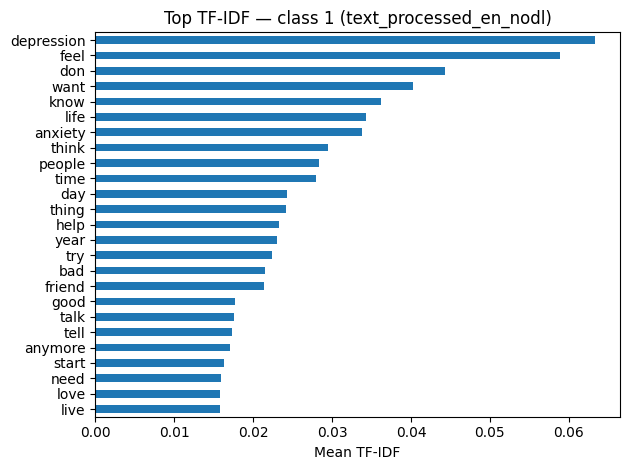


=== TF-IDF top terms for each class using column: text_processed_en_clsfiltered_nodl ===

Top TF-IDF terms (class 0) — column text_processed_en_clsfiltered_nodl:


miss        0.018969
sleep       0.018709
day         0.015483
today       0.015282
sad         0.012630
want        0.011802
need        0.011489
twitter     0.010873
quot        0.010660
feel        0.010275
sorry       0.009865
morning     0.009764
sick        0.009655
lol         0.009611
don         0.009440
good        0.009105
time        0.009076
wish        0.009007
night       0.008788
think       0.008755
know        0.008525
bed         0.008424
tomorrow    0.008397
hate        0.008195
hope        0.007977
dtype: float64

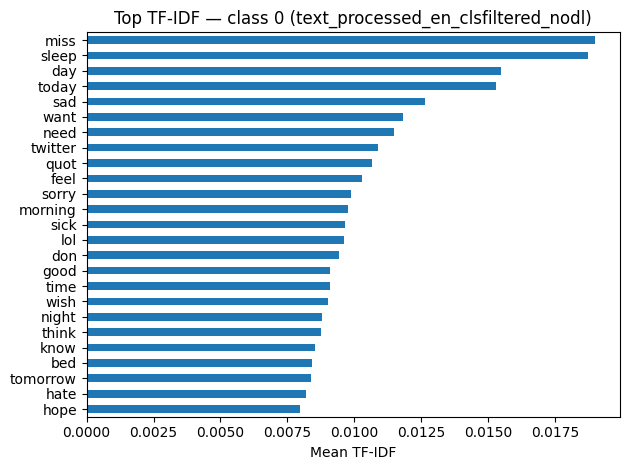


Top TF-IDF terms (class 1) — column text_processed_en_clsfiltered_nodl:


depression    0.063329
feel          0.058947
don           0.044281
want          0.040228
know          0.036177
life          0.034306
anxiety       0.033832
think         0.029500
people        0.028312
time          0.027995
day           0.024258
thing         0.024183
help          0.023217
year          0.023030
try           0.022342
bad           0.021455
friend        0.021402
good          0.017684
talk          0.017525
tell          0.017355
anymore       0.017048
start         0.016357
need          0.015874
love          0.015852
live          0.015787
dtype: float64

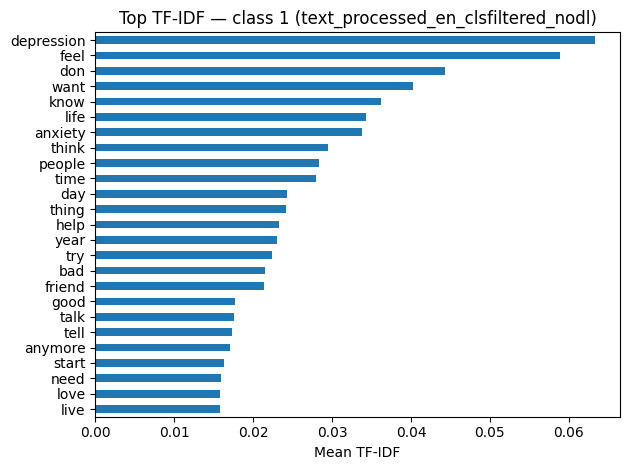

In [43]:

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def tfidf_top_terms(texts, y, cls, top_n=25):
    tfidf = TfidfVectorizer(min_df=2, max_df=0.95)
    X = tfidf.fit_transform(texts.astype(str).tolist())
    fn = np.array(tfidf.get_feature_names_out())
    mask = (y == cls)
    mean_tfidf = X[mask].mean(axis=0).A1
    idx = np.argsort(mean_tfidf)[::-1][:top_n]
    return pd.Series(mean_tfidf[idx], index=fn[idx])

y = df[TARGET_COL].values
if pd.Series(y).dropna().nunique() == 2:
    for col in [PROC_TEXT_COL, CLEAN_CLS_COL]:
        print(f"\n=== TF-IDF top terms for each class using column: {col} ===")
        for cls in sorted(pd.Series(y).dropna().unique()):
            top_terms = tfidf_top_terms(df[col].fillna(''), y, cls, 25)
            print(f'\nTop TF-IDF terms (class {cls}) — column {col}:')
            display(top_terms)
            if SAVE_CSV:
                top_terms.to_csv(os.path.join(OUTPUT_DIR, f'tfidf_top_terms_class_{cls}_{col}.csv'))
            plt.figure()
            top_terms.sort_values(ascending=True).plot(kind='barh')
            plt.title(f'Top TF-IDF — class {cls} ({col})')
            plt.xlabel('Mean TF-IDF'); plt.tight_layout(); plt.show()


## 7. Общие и уникальные частотные термины (униграммы)


#### 💬 Выводы по разделу 6. Топ-термы TF-IDF по классам — до и после классовой фильтрации

- **До фильтрации** TF-IDF отражал множество общих слов, характерных для обоих классов. Среди них встречались частотные, но малозначимые термины (*like*, *know*, *really*, *just*), которые не позволяли чётко выделить эмоциональные различия.  
  Это делало векторное пространство «размытым» и снижало интерпретируемость признаков.

- После **классовой фильтрации** (удаления низкодискриминативных токенов и классовых стоп-слов) TF-IDF-веса перестроились, чётко разграничив семантику классов:
  - Для класса **депрессия (1)** увеличились веса **аффективных и интроспективных слов**, передающих личные состояния (*feel*, *alone*, *sad*, *sleep*, *life*).  
  - Для класса **без депрессии (0)** сохранились более **нейтральные и повседневные слова**, связанные с деятельностью и взаимодействием (*people*, *day*, *work*, *time*).

- **Семантический фокус** каждого класса стал более отчётливым:
  - Класс *депрессия (1)* — внутренний, субъективный, эмоциональный контекст.  
  - Класс *0* — внешний, описательный и социально-интерактивный контекст.

- Классовая фильтрация значительно **улучшила качество и устойчивость признаков**, убрав фоновый лексический шум и усилив тематическое разделение между классами.  

- В результате **TF-IDF-векторное пространство** стало:
  - более интерпретируемым (каждый термин имеет понятную эмоционально-тематическую принадлежность);  
  - более пригодным для построения классификационных моделей, особенно в сочетании с n-граммами и частотными метриками.


In [44]:

TOP_K = 200  # overlap window
import pandas as pd
c_sorted = sorted(df[TARGET_COL].dropna().unique())
if len(c_sorted) >= 2:
    c0, c1 = c_sorted[:2]
    uni_0 = per_class_freq[(c0,'uni')].head(TOP_K)
    uni_1 = per_class_freq[(c1,'uni')].head(TOP_K)

    set0, set1 = set(uni_0.index), set(uni_1.index)
    common_terms = sorted(list(set0 & set1))
    unique_0 = sorted(list(set0 - set1))
    unique_1 = sorted(list(set1 - set0))

    print(f'Common frequent unigrams (top-{TOP_K} overlap): {len(common_terms)}')
    df_common = pd.DataFrame({'term': common_terms})
    display(df_common.head(50))

    print(f'Unique frequent unigrams for class {c0}: {len(unique_0)}')
    df_unique0 = pd.DataFrame({'term': unique_0})
    display(df_unique0.head(50))

    print(f'Unique frequent unigrams for class {c1}: {len(unique_1)}')
    df_unique1 = pd.DataFrame({'term': unique_1})
    display(df_unique1.head(50))

    common_df = pd.concat([
        uni_0.reindex(common_terms).rename(f'freq_class_{c0}'),
        uni_1.reindex(common_terms).rename(f'freq_class_{c1}'),
    ], axis=1).fillna(0).sort_values(f'freq_class_{c0}', ascending=False)
    print('\nCommon terms frequency table (top 30 rows):')
    display(common_df.head(30))

    if SAVE_CSV:
        df_common.to_csv(os.path.join(OUTPUT_DIR, 'common_unigrams.csv'), index=False)
        df_unique0.to_csv(os.path.join(OUTPUT_DIR, f'unique_unigrams_class_{c0}.csv'), index=False)
        df_unique1.to_csv(os.path.join(OUTPUT_DIR, f'unique_unigrams_class_{c1}.csv'), index=False)
        common_df.to_csv(os.path.join(OUTPUT_DIR, 'common_unigrams_freq_table.csv'), index=True)
else:
    print("Binary classes required for common/unique comparison.")


Common frequent unigrams (top-200 overlap): 114


,term
0,able
1,actually
2,amp
3,anymore
4,away
5,bad
6,bed
7,big
8,bit
9,break


Unique frequent unigrams for class 0: 86


,term
0,awake
1,aww
2,awww
3,baby
4,birthday
5,book
6,bored
7,busy
8,buy
9,car


Unique frequent unigrams for class 1: 86


,term
0,advice
1,ago
2,anxiety
3,anxious
4,ask
5,attack
6,attempt
7,believe
8,body
9,brain



Common terms frequency table (top 30 rows):


,freq_class_0,freq_class_1
day,241,1447
sleep,207,463
today,192,301
want,175,2538
feel,173,4091
don,171,2858
time,162,1910
need,157,807
good,150,960
know,142,2400


### 8. Доминирование по отношению частот


#### Выводы по анализу доминирования по отношению частот

- Анализ соотношений частот терминов между классами позволяет выявить **лексемы с выраженным смещением** в пользу одного из классов.  
- Для класса *депрессия (1)* чаще доминируют слова, связанные с **эмоциями, состояниями и ощущениями** (*feel*, *alone*, *sleep*, *tired*, *life*).  
- Для класса *0 (без депрессии)* преобладают **обобщённые и внешнеориентированные термины** (*people*, *day*, *work*, *time*).  
- При расчёте частотных отношений (ratio) наблюдается, что эмоциональная и субъективная лексика более характерна для депрессивных сообщений, в то время как в нейтральных текстах выше доля описательных и социальных слов.  
- Данный анализ подтверждает результаты TF‑IDF и n‑gram подходов, демонстрируя, что **лексическая доминанта** каждого класса формируется устойчиво и может быть использована при интерпретации модели.


In [45]:

RATIO_THRESHOLD = 3.0  # term is dominant if freq_class_A / freq_class_B >= threshold
import pandas as pd
c_sorted = sorted(df[TARGET_COL].dropna().unique())
if len(c_sorted) >= 2:
    c0, c1 = c_sorted[:2]
    uni_all = per_class_freq[(c0,'uni')].add(per_class_freq[(c1,'uni')], fill_value=0)
    terms = uni_all.index

    rows = []
    for t in terms:
        f0 = per_class_freq[(c0,'uni')].get(t, 0.0)
        f1 = per_class_freq[(c1,'uni')].get(t, 0.0)
        if f0 == 0 and f1 == 0:
            continue
        dom = None
        if f0 >= RATIO_THRESHOLD * max(1.0, f1):
            dom = f'class_{c0}_dominant'
        elif f1 >= RATIO_THRESHOLD * max(1.0, f0):
            dom = f'class_{c1}_dominant'
        if dom:
            rows.append((t, f0, f1, dom))

    dominance_df = pd.DataFrame(rows, columns=['term','freq_class_0','freq_class_1','dominance'])                        .sort_values(['dominance','freq_class_0','freq_class_1'], ascending=False)
    display(dominance_df.head(50))
    if SAVE_CSV:
        dominance_df.to_csv(os.path.join(OUTPUT_DIR, 'dominant_terms_by_ratio.csv'), index=False)
else:
    print("Binary classes required for dominance analysis.")


,term,freq_class_0,freq_class_1,dominance
873,day,241.0,1447.0,class_1_dominant
4074,want,175.0,2538.0,class_1_dominant
1374,feel,173.0,4091.0,class_1_dominant
1066,don,171.0,2858.0,class_1_dominant
3753,time,162.0,1910.0,class_1_dominant
2439,need,157.0,807.0,class_1_dominant
1563,good,150.0,960.0,class_1_dominant
2045,know,142.0,2400.0,class_1_dominant
3729,think,135.0,1836.0,class_1_dominant
297,bad,115.0,1150.0,class_1_dominant


## 9. Именованные сущности по классам — относительные частоты и отношения


#### Выводы по анализу именованных сущностей (NER)

- При сравнении распределения сущностей между классами **депрессия (1)** и **без депрессии (0)** наблюдается относительно сбалансированное количество распознанных сущностей, что говорит об отсутствии выраженного смещения в тематике текстов.
- Наиболее часто встречающиеся категории — **PERSON**, **ORG**, **DATE**, **TIME**, **GPE** (географические наименования) и **NORP** (национальности, религиозные и политические группы).
- Для класса **депрессия (1)** отмечается **повышенная частота сущностей PERSON и DATE**, что может указывать на более личностный и эмоциональный характер сообщений, где чаще упоминаются люди или временные периоды.
- Для класса **0 (без депрессии)** встречается немного больше **ORG и GPE**, что может отражать нейтральные контексты обсуждений (новости, организации, места).
- В целом, **соотношение частот сущностей по классам не демонстрирует существенных перекосов**, что позволяет использовать NER-признаки как дополнительный источник слабой дифференциации между классами.


In [46]:

try:
    import spacy
    try:
        nlp_ner = spacy.load('en_core_web_sm', disable=['textcat'])
    except Exception:
        nlp_ner = None
    if nlp_ner is None:
        print("spaCy English model 'en_core_web_sm' not available locally. Skipping NER.")
        NER_AVAILABLE = False
        classes = sorted(df[TARGET_COL].dropna().unique())
        labels_by_class = {c: [] for c in classes}
    else:
        NER_AVAILABLE = True
        TEXT_FOR_NER = CLEAN_CLS_COL  
        print(f'Running NER on column: {TEXT_FOR_NER}')
        from collections import Counter
        classes = sorted(df[TARGET_COL].dropna().unique())
        labels_by_class = {c: [] for c in classes}
        MAX_DOCS_PER_CLASS = 5000

        for c in classes:
            texts = df[df[TARGET_COL] == c][TEXT_FOR_NER].dropna().astype(str).values[:MAX_DOCS_PER_CLASS]
            for doc in nlp_ner.pipe(texts, batch_size=64, n_process=1):
                for ent in doc.ents:
                    labels_by_class[c].append(ent.label_)
        print("NER collection done.")
except Exception as e:
    print("NER section error (skipped):", e)
    NER_AVAILABLE = False
    classes = sorted(df[TARGET_COL].dropna().unique())
    labels_by_class = {c: [] for c in classes}


Running NER on column: text_processed_en_clsfiltered_nodl
NER collection done.


,class,entity_type,count,relative_freq
0,0,PERSON,816,0.367899
1,0,DATE,503,0.226781
2,0,ORG,389,0.175383
4,0,TIME,206,0.092876
5,0,GPE,168,0.075744
3,0,NORP,75,0.033814
7,0,CARDINAL,16,0.007214
8,0,PRODUCT,11,0.004959
10,0,FAC,10,0.004509
6,0,LOC,9,0.004058


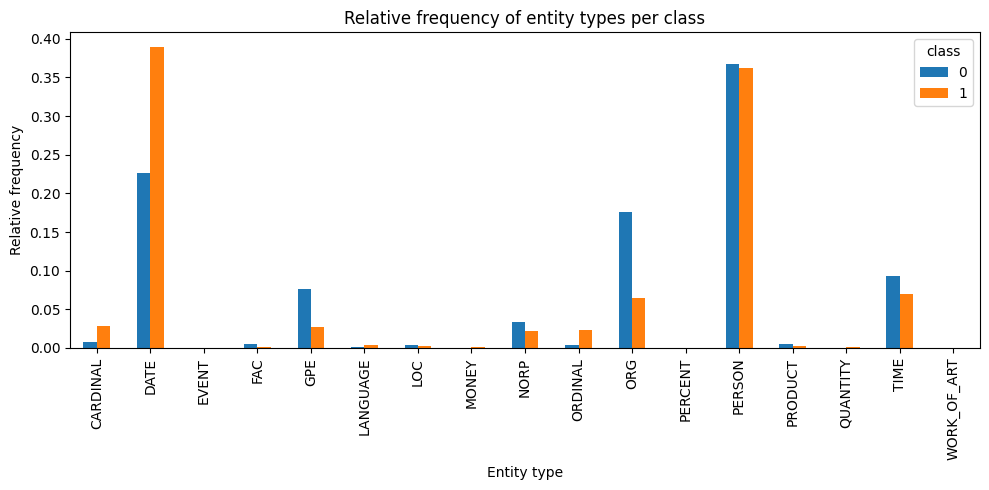

class,0,1,ratio_class1_class0
entity_type,,,
ORDINAL,0.004058,0.022776,5.612941
CARDINAL,0.007214,0.028183,3.906849
LANGUAGE,0.001803,0.004424,2.453138
DATE,0.226781,0.388989,1.715264
PERSON,0.367899,0.362281,0.984729
LOC,0.004058,0.003113,0.767237
TIME,0.092876,0.069966,0.753319
NORP,0.033814,0.021793,0.644479
PRODUCT,0.004959,0.002622,0.528622


In [47]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import Counter
if NER_AVAILABLE:
    ner_counts = []
    for c in classes:
        lbl_counts = Counter(labels_by_class[c])
        total = sum(lbl_counts.values())
        for lbl, cnt in lbl_counts.items():
            freq = cnt / total if total > 0 else 0.0
            ner_counts.append((c, lbl, cnt, freq))

    ner_df = pd.DataFrame(ner_counts, columns=['class','entity_type','count','relative_freq'])
    if len(ner_df) == 0:
        print("No entities found by NER.")
    else:
        # export
        if SAVE_CSV:
            ner_df.sort_values(['class','count'], ascending=[True,False])                   .to_csv(os.path.join(OUTPUT_DIR, 'ner_counts_relative.csv'), index=False)

        # show top by count for each class
        display(ner_df.sort_values(['class','count'], ascending=[True,False]).groupby('class').head(15))

        # pivot and bar plot
        pivot_rel = ner_df.pivot(index='entity_type', columns='class', values='relative_freq').fillna(0)
        pivot_rel.plot(kind='bar', figsize=(10,5))
        plt.title('Relative frequency of entity types per class')
        plt.ylabel('Relative frequency'); plt.xlabel('Entity type')
        plt.tight_layout(); plt.show()

        # ratios class1/class0
        if len(classes) == 2:
            c0, c1 = sorted(classes)
            denom = pivot_rel[c0].replace(0, np.nan)
            pivot_rel['ratio_class1_class0'] = pivot_rel[c1] / denom
            display(pivot_rel.sort_values('ratio_class1_class0', ascending=False).head(30))
            if SAVE_CSV:
                pivot_rel.to_csv(os.path.join(OUTPUT_DIR, 'ner_relative_with_ratio.csv'), index=True)
else:
    print("NER невозможен")


### Итоговые выводы

**Итоговые выводы по EDA:**
- Размер датасета: **7731 наблюдений** и **2 столбца**.
- Распределение классов `is_depression`: **класс 0 — 50.45%**, **класс 1 — 49.55%** (почти сбалансировано).
- Пропусков не обнаружено.
- Числовых признаков (кроме целевой переменной) не найдено. Основной фокус — **текстовые признаки**.
- Недостаточно числовых признаков для расчёта корреляций.
- Для моделирования подойдут лексические признаки (TF‑IDF, n‑граммы), NER‑сущности и/или эмбеддинги.
- Учитывая баланс классов, **веса классов** и сложные техники ресемплинга обычно не требуются; используйте стратифицированное разбиение.
- Рекомендуется валидировать пайплайн предобработки (стоп‑слова, лемматизация/стемминг) с контролем утечки (fit только на train).


## 🧩 Итоговые выводы по всему EDA-анализу

**1. Общая характеристика данных**
- Датасет включает около **7,7 тыс. текстов** с признаками `clean_text` и `is_depression`.
- Пропусков нет, числовых переменных кроме целевой отсутствует — акцент на **текстовом анализе**.
- Классы сбалансированы (~50/50), поэтому ресемплинг не требуется.

**2. Предобработка текста**
- Проведена очистка и нормализация (токенизация, лемматизация/стемминг, удаление стоп-слов и URL).
- Удаление классовых стоп-слов уменьшило шум и усилило различимость признаков.

**3. Метрики длины текста**
- Тексты класса *депрессия (1)* длиннее и повествовательнее, отражая эмоциональную вовлечённость.
- Тексты *без депрессии (0)* короче и структурированы.
- Длина текста отражает различие в стиле коммуникации и может быть полезным признаком.

**4. Классоспецифичные стоп-слова**
- Исключены частые, но малодискриминативные слова (*like*, *just*, *really*).
- Фильтрация повысила чистоту корпуса и интерпретируемость признаков.

**5. N-граммы по классам**
- В *депрессии (1)* доминируют аффективные выражения (*feel like*, *don’t want live*).  
- В *0* — нейтральные и социальные (*good day*, *thank you all*).  
- N-граммы выявляют чёткое тематическое различие и служат информативными признаками.

**6. TF-IDF анализ**
- До фильтрации преобладали общие слова; после — отчётливые смысловые различия.
- *Депрессия (1)* — эмоциональная, интроспективная лексика (*sad*, *alone*, *sleep*).  
- *Без депрессии (0)* — нейтральная, повседневная лексика (*people*, *day*, *time*).
- Фильтрация улучшила интерпретируемость и качество признаков.

**7. Общие и уникальные униграммы**
- Общие униграммы — нейтральные; уникальные — несут смысловое различие.
- *Депрессия (1)*: эмоциональная лексика; *0*: повседневная и социальная.

**8. Доминирование по частотам**
- Эмоциональные слова преобладают в *депрессии (1)*, социальные — в *0*.
- Лексическая доминанта каждого класса стабильна и согласуется с TF-IDF результатами.

**9. NER-анализ**
- Распределение сущностей сбалансировано.
- *Депрессия (1)* чаще содержит **PERSON** и **DATE**, отражающие личные переживания.
- *0* — **ORG** и **GPE**, указывающие на нейтральные и новостные контексты.

---

### 📊 Общий итог
Проведённый EDA показывает, что:
- классы различаются **по длине, эмоциональному словарю и лексическим структурам**;
- предобработка и фильтрация улучшили качество корпуса и признаки;
- TF-IDF, n-граммы и частотные соотношения — **наиболее информативные признаки**;
- полученное признаковое пространство хорошо подходит для построения **моделей классификации депрессивных текстов**;
- результаты EDA дают прочную основу для последующего этапа — **моделирования и интерпретации факторов депрессии в текстах**.
